<a href="https://colab.research.google.com/github/Daniel-Godwin/Explainable-Real-Time-Surgical-Instrument-Detection/blob/main/ASYU2026_YOLOv11_XSurg_FIXED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ASYU 2026 — YOLOv11-XSurg Experiment Notebook
### Explainable Real-Time Surgical Instrument Detection Using Lightweight YOLOv11
**Author:** [Your Name] — Oka University  
**Conference:** ASYU 2026 (IEEE)  
**Deadline:** June 10, 2026  

> Run cells top-to-bottom on **Google Colab GPU (T4)** or a local NVIDIA GPU.  
> All figures and tables are saved automatically to `asyu2026_experiment/figures/` and `asyu2026_experiment/results/`.

## Cell 1 — Install Dependencies

In [1]:
# ── Install all required packages ─────────────────────────────
import subprocess, sys

pkgs = [
    "ultralytics",
    "grad-cam",          # pytorch-grad-cam
    "matplotlib",
    "seaborn",
    "pandas",
    "opencv-python-headless",
    "PyYAML",
]

for pkg in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("✅ All packages installed.")


✅ All packages installed.


In [2]:
print("Upgrading ultralytics to the latest version...")
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "ultralytics", "-q"])
print("✅ Ultralytics upgraded.")

Upgrading ultralytics to the latest version...
✅ Ultralytics upgraded.


## Cell 2 — Imports & Environment Check

In [3]:
import os, cv2, yaml, json, time, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torchvision.transforms as T

from ultralytics import YOLO
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

warnings.filterwarnings("ignore")

# ── Verify GPU ─────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device      : {device}")
if device == "cuda":
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
    print(f"VRAM        : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"PyTorch     : {torch.__version__}")

# ── Global paths ───────────────────────────────────────────────
BASE_DIR    = Path("asyu2026_experiment")
DATA_DIR    = BASE_DIR / "dataset"
MODEL_DIR   = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = BASE_DIR / "figures"
TABLES_DIR  = BASE_DIR / "tables"

for d in [DATA_DIR, MODEL_DIR, RESULTS_DIR, FIGURES_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMG_SIZE   = 640
BATCH_SIZE = 16
CLASS_NAMES = ["grasper","bipolar","hook","scissors",
               "clipper","irrigator","specimenbag"]

print(f"\nWorking dir : {BASE_DIR.resolve()}")
print(f"Figures     → {FIGURES_DIR.resolve()}")
print(f"Tables      → {TABLES_DIR.resolve()}")
print("✅ Environment ready.")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device      : cuda
GPU         : NVIDIA A100-SXM4-40GB
VRAM        : 42.4 GB
PyTorch     : 2.11.0+cu128

Working dir : /content/asyu2026_experiment
Figures     → /content/asyu2026_experiment/figures
Tables      → /content/asyu2026_experiment/tables
✅ Environment ready.


## Cell 3 — Dataset Setup (m2cai16-tool-locations)

**No account, no API key needed.** We pull directly from the original
research repo (Jin et al., the same paper cited as [2] in your references)
on GitHub, which hosts the dataset in PASCAL VOC XML format. This cell
auto-converts VOC XML → YOLO `.txt` format and builds `data.yaml`.

Source: `github.com/ajin12/tooldetection` — official repo for
*"Tool Detection and Operative Skill Assessment in Surgical Videos"*
(Jin et al., 2018), extending the original m2cai16-tool dataset with
2,532 spatially-annotated frames across 7 instrument classes.

In [4]:
# ── Clone the official m2cai16-tool-locations repo ──────────────
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/ajin12/tooldetection.git"
REPO_DIR = Path("tooldetection_repo")

if not REPO_DIR.exists():
    print("Cloning m2cai16-tool-locations source repo...")
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)],
                   check=True)
    print("Clone complete.")
else:
    print("Repo already cloned.")

# VOC2007-style layout inside the repo (corrected path)
VOC_ROOT = REPO_DIR / "m2cai16-tool-locations"
VOC_ANNOTATIONS = VOC_ROOT / "Annotations"
VOC_IMAGES      = VOC_ROOT / "JPEGImages"
VOC_IMAGESETS   = VOC_ROOT / "ImageSets" / "Main"

print(f"Annotations dir : {VOC_ANNOTATIONS}  (exists={VOC_ANNOTATIONS.exists()})")
print(f"Images dir       : {VOC_IMAGES}  (exists={VOC_IMAGES.exists()})")

if not VOC_ANNOTATIONS.exists():
    print("""
    ──────────────────────────────────────────────────────────
    [WARN] Expected VOC path not found in the cloned repo.
    The repo structure may have changed. Browse it manually:

        !find tooldetection_repo -iname "*.xml" | head -5
        !find tooldetection_repo -iname "*.jpg" | head -5

    Then update VOC_ANNOTATIONS / VOC_IMAGES above to match.
    ──────────────────────────────────────────────────────────
    """)

Cloning m2cai16-tool-locations source repo...
Clone complete.
Annotations dir : tooldetection_repo/m2cai16-tool-locations/Annotations  (exists=True)
Images dir       : tooldetection_repo/m2cai16-tool-locations/JPEGImages  (exists=True)


In [5]:
# ── Convert VOC XML annotations -> YOLO .txt format ─────────────
import xml.etree.ElementTree as ET
import shutil, random

random.seed(42)

# Map dataset's tool names to our 7-class scheme (case-insensitive,
# handles minor naming variants seen across m2cai16 annotation tools)
NAME_MAP = {
    "grasper": "grasper",
    "bipolar": "bipolar",
    "hook": "hook",
    "scissors": "scissors",
    "clipper": "clipper", "clip applier": "clipper", "clip_applier": "clipper",
    "irrigator": "irrigator",
    "specimenbag": "specimenbag", "specimen bag": "specimenbag", "specimen_bag": "specimenbag",
}

def voc_to_yolo_box(xmin, ymin, xmax, ymax, img_w, img_h):
    """Convert VOC corner-box to YOLO normalised center-box."""
    x_center = ((xmin + xmax) / 2) / img_w
    y_center = ((ymin + ymax) / 2) / img_h
    w = (xmax - xmin) / img_w
    h = (ymax - ymin) / img_h
    return x_center, y_center, w, h


def parse_voc_xml(xml_path):
    """Parse a single VOC XML file -> (img_filename, img_w, img_h, [(cls, box)])"""
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.findtext("filename")
    size = root.find("size")
    img_w = int(size.findtext("width"))
    img_h = int(size.findtext("height"))

    objects = []
    for obj in root.findall("object"):
        raw_name = obj.findtext("name").strip().lower()
        cls_name = NAME_MAP.get(raw_name)
        if cls_name is None:
            continue   # skip unrecognised classes
        bnd = obj.find("bndbox")
        xmin = float(bnd.findtext("xmin"))
        ymin = float(bnd.findtext("ymin"))
        xmax = float(bnd.findtext("xmax"))
        ymax = float(bnd.findtext("ymax"))
        objects.append((cls_name, (xmin, ymin, xmax, ymax)))

    return filename, img_w, img_h, objects


# ── Run conversion across all annotation files ──────────────────
xml_files = sorted(VOC_ANNOTATIONS.glob("*.xml")) if VOC_ANNOTATIONS.exists() else []
print(f"Found {len(xml_files)} annotation files.")

converted = []   # list of (image_path, [yolo_lines])
skipped = 0

for xml_path in xml_files:
    try:
        filename, img_w, img_h, objects = parse_voc_xml(xml_path)
        if not objects:
            skipped += 1
            continue

        img_path = VOC_IMAGES / filename
        if not img_path.exists():
            # try common extension fallbacks
            alt = VOC_IMAGES / (xml_path.stem + ".jpg")
            img_path = alt if alt.exists() else None
        if img_path is None:
            skipped += 1
            continue

        yolo_lines = []
        for cls_name, box in objects:
            cls_idx = CLASS_NAMES.index(cls_name)
            xc, yc, w, h = voc_to_yolo_box(*box, img_w, img_h)
            yolo_lines.append(f"{cls_idx} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}")

        converted.append((img_path, yolo_lines))
    except Exception as e:
        skipped += 1
        continue

print(f"Converted : {len(converted)} frames")
print(f"Skipped   : {skipped} frames (no objects / missing image / parse error)")

# ── Split train/val/test (80/10/10, matching Jin et al. protocol) ──
random.shuffle(converted)
n = len(converted)
n_train = int(n * 0.80)
n_val   = int(n * 0.10)

splits = {
    "train": converted[:n_train],
    "val":   converted[n_train:n_train+n_val],
    "test":  converted[n_train+n_val:],
}

for split_name, items in splits.items():
    img_out = DATA_DIR / "images" / split_name
    lbl_out = DATA_DIR / "labels" / split_name
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    for img_path, yolo_lines in items:
        dest_img = img_out / img_path.name
        shutil.copy(img_path, dest_img)
        dest_lbl = lbl_out / (img_path.stem + ".txt")
        dest_lbl.write_text("\n".join(yolo_lines))

    print(f"  {split_name:5s}: {len(items)} frames -> {img_out}")

print("\n✅ Dataset conversion complete — no Roboflow / API key required.")


Found 2811 annotation files.
Converted : 2811 frames
Skipped   : 0 frames (no objects / missing image / parse error)
  train: 2248 frames -> asyu2026_experiment/dataset/images/train
  val  : 281 frames -> asyu2026_experiment/dataset/images/val
  test : 282 frames -> asyu2026_experiment/dataset/images/test

✅ Dataset conversion complete — no Roboflow / API key required.


## Cell 3b — Generate `data.yaml`

Points Ultralytics YOLOv11 at the converted train/val/test splits.

In [6]:
data_yaml = {
    "path":  str(DATA_DIR.resolve()),
    "train": "images/train",
    "val":   "images/val",
    "test":  "images/test",
    "nc":    len(CLASS_NAMES),
    "names": CLASS_NAMES
}

yaml_path = DATA_DIR / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"✅ data.yaml written → {yaml_path}")
print(f"   Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}")
print(f"   Train: {len(splits['train'])}  Val: {len(splits['val'])}  Test: {len(splits['test'])}")


✅ data.yaml written → asyu2026_experiment/dataset/data.yaml
   Classes (7): ['grasper', 'bipolar', 'hook', 'scissors', 'clipper', 'irrigator', 'specimenbag']
   Train: 2248  Val: 281  Test: 282


## Cell 4 — Load YOLOv11n (COCO pretrained baseline)

In [7]:
print("Loading YOLOv11n (COCO pretrained)...")
model = YOLO("yolo11n.pt")    # auto-downloads ~6 MB

# Check if the model loaded successfully
if model.model is None:
    print("ERROR: YOLO model failed to load from 'yolo11n.pt'.")
    print("This might be due to an invalid or corrupted model file, or incompatibility with the installed Ultralytics version.")
    # Exit or raise an error to prevent further execution with a non-existent model
    raise ValueError("YOLO model did not initialize correctly.")

# Calculate baseline parameters directly from the model's PyTorch module
n_params_base = sum(p.numel() for p in model.model.parameters())

# Attempt to get GFLOPs using model.info(). This method sometimes returns None or errors.
gflops_base = 0.0  # Default value in case of failure or None return
model_stats_obj = None
try:
    model_stats_obj = model.info(verbose=False)
except Exception as e:
    print(f"WARNING: model.info() failed with an exception: {e}. GFLOPs set to {gflops_base:.1f}.")

if model_stats_obj is not None:
    try:
        # total_ops is usually in FLOPs; convert to GFLOPs (1 billion FLOPs)
        gflops_base = model_stats_obj.total_ops / 1e9
    except AttributeError:
        print(f"WARNING: model.info() returned an object without 'total_ops' attribute. GFLOPs set to {gflops_base:.1f}.")
else:
    print(f"WARNING: model.info() returned None. Could not retrieve GFLOPs. GFLOPs set to {gflops_base:.1f}.")


print(f"\nBaseline params : {n_params_base/1e6:.2f} M")
print(f"Baseline GFLOPs : {gflops_base:.1f}")
print("✅ Model loaded.")

Loading YOLOv11n (COCO pretrained)...

Baseline params : 2.62 M
Baseline GFLOPs : 0.0
✅ Model loaded.


In [ ]:
# List the contents of the tooldetection_repo to find actual data paths
print("Listing contents of tooldetection_repo:")
!ls -R tooldetection_repo

## Cell 5 — Training

> Expected runtime: ~2–3 hrs on Colab T4 for 100 epochs.  
> Reduce `EPOCHS = 30` for a quick smoke-test.

In [8]:
EPOCHS = 100    # set to 30 for quick test

yaml_path = DATA_DIR / "data.yaml"

print(f"Starting training — {EPOCHS} epochs, batch {BATCH_SIZE}, img {IMG_SIZE}\u00d7{IMG_SIZE}")

train_results = model.train(
    data         = str(yaml_path),
    epochs       = EPOCHS,
    imgsz        = IMG_SIZE,
    batch        = BATCH_SIZE,
    device       = device,
    # \u2500\u2500 Learning rate (cosine annealing) \u2500\u2500
    lr0          = 0.01,
    lrf          = 0.001,
    momentum     = 0.937,
    weight_decay = 0.0005,
    warmup_epochs= 3,
    # \u2500\u2500 Augmentation \u2500\u2500
    hsv_h        = 0.015,
    hsv_s        = 0.7,
    hsv_v        = 0.4,
    mosaic       = 1.0,
    mixup        = 0.2,
    fliplr       = 0.5,
    label_smoothing = 0.1,
    # \u2500\u2500 Early stopping \u2500\u2500
    patience     = 30,
    # \u2500\u2500 Output \u2500\u2500
    project      = str(RESULTS_DIR),
    name         = "yolov11_xsurg",
    save         = True,
    save_period  = 10,
    plots        = True,
    verbose      = True,
)

# \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
# CRITICAL FIX: Do NOT guess the save path. Ultralytics tells us
# exactly where it saved everything via trainer.save_dir. We store
# this once, persist it to disk, and every later cell reuses it \u2014
# no more hardcoded "runs/detect/..." guessing, ever.
# \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
RUN_DIR = Path(model.trainer.save_dir)        # e.g. .../runs/detect/yolov11_xsurg
BEST_PT = RUN_DIR / "weights" / "best.pt"
LAST_PT = RUN_DIR / "weights" / "last.pt"

assert BEST_PT.exists(), f"best.pt not found at {BEST_PT} \u2014 check training actually finished."

# Persist the path so it survives kernel restarts / new sessions
with open(BASE_DIR / "last_run_dir.txt", "w") as f:
    f.write(str(RUN_DIR))

print(f"\n\u2705 Training complete.")
print(f"   Run dir     \u2192 {RUN_DIR}")
print(f"   Best weights\u2192 {BEST_PT}")


Starting training — 100 epochs, batch 16, img 640×640
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=asyu2026_experiment/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.2, m

## Cell 5b — Path Resolver (run this if you ever restart the kernel)

This cell finds your trained model regardless of session restarts. **Every cell from here on uses `RUN_DIR` / `BEST_PT` defined here — no hardcoded paths.**

In [9]:
import torch
from pathlib import Path

# Re-declare globals in case the kernel was restarted
device      = "cuda" if torch.cuda.is_available() else "cpu"
BASE_DIR    = Path("asyu2026_experiment")
DATA_DIR    = BASE_DIR / "dataset"
RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = BASE_DIR / "figures"
TABLES_DIR  = BASE_DIR / "tables"
for d in [DATA_DIR, RESULTS_DIR, FIGURES_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMG_SIZE    = 640
BATCH_SIZE  = 16
CLASS_NAMES = ["grasper","bipolar","hook","scissors",
               "clipper","irrigator","specimenbag"]
yaml_path   = DATA_DIR / "data.yaml"


def get_run_dir():
    """
    Reliably locate the YOLO training run directory, in priority order:
      1. RUN_DIR already in memory (same session, ran Cell 5 already)
      2. asyu2026_experiment/last_run_dir.txt (written by Cell 5)
      3. Search the filesystem for any "yolov11_xsurg/weights/best.pt"
    Never hardcodes "runs/detect/..." \u2014 works regardless of which
    Ultralytics version / save convention is active.
    """
    # 1. Already in memory?
    if "RUN_DIR" in globals() and Path(globals()["RUN_DIR"]).exists():
        return Path(globals()["RUN_DIR"])

    # 2. Saved pointer file from training cell?
    pointer = BASE_DIR / "last_run_dir.txt"
    if pointer.exists():
        candidate = Path(pointer.read_text().strip())
        if (candidate / "weights" / "best.pt").exists():
            return candidate

    # 3. Last resort: search the whole filesystem
    matches = list(Path(".").rglob("yolov11_xsurg/weights/best.pt"))
    matches += list(Path("/content").rglob("yolov11_xsurg/weights/best.pt")) \
               if Path("/content").exists() else []
    matches = sorted(set(m.resolve() for m in matches),
                      key=lambda p: p.stat().st_mtime, reverse=True)
    if matches:
        return matches[0].parent.parent   # weights/best.pt -> run_dir

    raise FileNotFoundError(
        "Could not locate a trained model anywhere. "
        "Run Cell 5 (Training) first, or check that training "
        "actually completed and saved a best.pt file."
    )


RUN_DIR = get_run_dir()
BEST_PT = RUN_DIR / "weights" / "best.pt"
LAST_PT = RUN_DIR / "weights" / "last.pt"
RESULTS_CSV = RUN_DIR / "results.csv"

print(f"\u2705 Run directory found:")
print(f"   RUN_DIR : {RUN_DIR}")
print(f"   BEST_PT : {BEST_PT}  (exists={BEST_PT.exists()})")
print(f"   results.csv exists={RESULTS_CSV.exists()}")


✅ Run directory found:
   RUN_DIR : /content/runs/detect/asyu2026_experiment/results/yolov11_xsurg
   BEST_PT : /content/runs/detect/asyu2026_experiment/results/yolov11_xsurg/weights/best.pt  (exists=True)
   results.csv exists=True


## Cell 6 — Validation & Metrics for Table I

In [10]:
import pandas as pd
from ultralytics import YOLO

# Uses RUN_DIR / BEST_PT from Cell 5b resolver \u2014 no hardcoded paths
best_model = YOLO(str(BEST_PT))

val_metrics = best_model.val(
    data    = str(yaml_path.resolve()),
    split   = "test",
    imgsz   = IMG_SIZE,
    batch   = BATCH_SIZE,
    device  = device,
    plots   = True,
    save_json = True,
    project = str(RESULTS_DIR),
    name    = "yolov11_xsurg_val",
    verbose = False,
)

map50   = val_metrics.box.map50
map5095 = val_metrics.box.map
prec    = val_metrics.box.mp
rec     = val_metrics.box.mr

# \u2500\u2500 Save metrics to CSV \u2500\u2500
metrics_df = pd.DataFrame({
    "mAP50":    [round(map50, 4)],
    "mAP50-95": [round(map5095, 4)],
    "Precision":[round(prec, 4)],
    "Recall":   [round(rec, 4)],
})
metrics_csv = TABLES_DIR / "table1_ours_row.csv"
metrics_df.to_csv(metrics_csv, index=False)

print("=" * 50)
print("  TABLE I \u2014 YOLOv11-XSurg row (paste into LaTeX)")
print("=" * 50)
print(f"  mAP@0.5      : {map50:.4f}")
print(f"  mAP@0.5:0.95 : {map5095:.4f}")
print(f"  Precision    : {prec:.4f}")
print(f"  Recall       : {rec:.4f}")
print(f"\n\u2705 Saved \u2192 {metrics_csv}")


Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11n summary (fused): 101 layers, 2,583,517 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1099.9±445.8 MB/s, size: 30.7 KB)
val: Scanning /content/asyu2026_experiment/dataset/labels/test... 282 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 282/282 1.6Kit/s 0.2s
val: New cache created: /content/asyu2026_experiment/dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 8.2it/s 2.2s
                   all        282        383      0.966      0.949      0.968      0.626
Speed: 0.7ms preprocess, 2.0ms inference, 0.0ms loss, 1.1ms postprocess per image
Saving /content/runs/detect/asyu2026_experiment/results/yolov11_xsurg_val/predictions.json...
Results saved to /content/runs/detect/asyu2026_experiment/results/yolov11_xsurg_val
  TABLE I — YOLOv11-XSurg row (paste i

## Cell 7 — FPS Benchmark

In [11]:
import time
import numpy as np
import pandas as pd
from ultralytics import YOLO

best_model = YOLO(str(BEST_PT))   # from Cell 5b resolver

# Warm-up
for _ in range(10):
    _ = best_model.predict(
        source=np.random.randint(0,255,(IMG_SIZE,IMG_SIZE,3),dtype=np.uint8),
        verbose=False, device=device)

# Timed run
N = 100
t0 = time.perf_counter()
for _ in range(N):
    _ = best_model.predict(
        source=np.random.randint(0,255,(IMG_SIZE,IMG_SIZE,3),dtype=np.uint8),
        verbose=False, device=device)
t1 = time.perf_counter()

ms_per_frame = (t1 - t0) / N * 1000
fps = 1000 / ms_per_frame

speed_csv = TABLES_DIR / "inference_speed.csv"
pd.DataFrame({"ms_per_frame":[round(ms_per_frame,2)],
              "FPS":[round(fps,1)]}).to_csv(speed_csv, index=False)

print(f"Inference   : {ms_per_frame:.2f} ms/frame")
print(f"FPS         : {fps:.1f}")
print(f"\n\u2705 Saved \u2192 {speed_csv}")


Inference   : 13.49 ms/frame
FPS         : 74.1

✅ Saved → asyu2026_experiment/tables/inference_speed.csv


## Cell 8 — Model Complexity (Params & GFLOPs)

In [13]:
import os
import pandas as pd
from ultralytics import YOLO
from ultralytics.utils.torch_utils import model_info

best_model = YOLO(str(BEST_PT))   # from Cell 5b resolver

model_stats = model_info(best_model.model, imgsz=IMG_SIZE, verbose=False)

n_params = 0.0
gflops = 0.0

if model_stats is not None and len(model_stats) == 2:
    n_params, gflops = model_stats
else:
    print("WARNING: model_info() returned None or an unexpected format. Parameters and GFLOPs set to 0.")

model_size_mb = os.path.getsize(str(BEST_PT)) / 1e6

complexity_csv = TABLES_DIR / "model_complexity.csv"
pd.DataFrame({
    "Params_M":     [round(n_params/1e6, 2)],
    "GFLOPs":       [round(gflops, 1)],
    "ModelSize_MB": [round(model_size_mb, 1)],
}).to_csv(complexity_csv, index=False)

print(f"Parameters  : {n_params/1e6:.2f} M")
print(f"GFLOPs      : {gflops:.1f}")
print(f"Model size  : {model_size_mb:.1f} MB")
print(f"\n\u2705 Saved \u2192 {complexity_csv}")

Parameters  : 0.00 M
GFLOPs      : 0.0
Model size  : 5.5 MB

✅ Saved → asyu2026_experiment/tables/model_complexity.csv


## Cell 9 — Grad-CAM Class (XAI Integration)

In [14]:
class YOLOGradCAM:
    """
    Wraps a trained YOLOv11 model with Grad-CAM explainability.
    Hooks into the final backbone convolutional layer.
    See paper Section III.C and Equations (1)-(2).
    """

    def __init__(self, model_path: str):
        self.yolo  = YOLO(model_path)
        self.model = self.yolo.model
        self.model.eval()
        self.target_layer = self._find_target_layer()
        print(f"Grad-CAM target layer : {type(self.target_layer).__name__}")

    def _find_target_layer(self):
        """Return last Conv2d in the backbone."""
        target = None
        for m in self.model.model.modules():
            if isinstance(m, nn.Conv2d):
                target = m
        return target

    def generate(self, image_path: str, class_idx: int = None) -> dict:
        """
        Generate Grad-CAM heatmap for one frame.

        Returns dict:
            original  – np.ndarray RGB (640,640,3)
            heatmap   – grayscale CAM (640,640)
            overlay   – Grad-CAM blended on image (RGB)
            boxes     – predicted bounding boxes (or None)
            class_idx – instrument class used for CAM
            class_name
        """
        img_bgr     = cv2.imread(image_path)
        img_rgb     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
        img_float   = img_resized.astype(np.float32) / 255.0

        # YOLO inference for boxes
        results = self.yolo.predict(
            source=image_path, imgsz=IMG_SIZE,
            device=device, verbose=False)
        preds = results[0].boxes

        # Pick class
        if class_idx is None and preds is not None and len(preds):
            class_idx = int(preds.cls[preds.conf.argmax()].cpu().item())
        class_idx = class_idx or 0

        # Build input tensor
        tensor = T.Compose([T.ToTensor(),
                             T.Resize((IMG_SIZE, IMG_SIZE))])(img_rgb)
        tensor = tensor.unsqueeze(0).to(device)
        tensor.requires_grad_(True) # Ensure gradients are tracked for Grad-CAM

        # --- Fix for RuntimeError: grad can be implicitly created only for scalar outputs ---
        # The default ClassifierOutputTarget expects a simple classification output.
        # For YOLO, the raw model output is complex (list of feature maps/detection heads).
        # We need a custom target that extracts a scalar class score from this.
        class YOLODetectionTarget:
            def __init__(self, class_index, model_output_idx=-1):
                # model_output_idx indicates which output from the model's forward pass
                # contains the detection predictions (usually the last one for Ultralytics YOLO)
                self.class_index = class_index
                self.model_output_idx = model_output_idx

            def __call__(self, model_output):
                # model_output from self.model(input_tensor) for Ultralytics YOLO is typically a list.
                # The last element usually contains the concatenated detection predictions.
                if isinstance(model_output, (list, tuple)):
                    # Assuming the last element is the detection head output tensor
                    detections = model_output[self.model_output_idx]
                else:
                    # Fallback if the output is already the detection tensor (e.g., if a wrapper is used)
                    detections = model_output

                # detections shape: (batch_size, num_preds, num_attributes)
                # num_attributes = (bbox_x, bbox_y, bbox_w, bbox_h, objectness_score, class_score_0, ..., class_score_N-1)
                # We want the max class score for self.class_index. Need to handle potential batch dim.
                # For Grad-CAM, we usually process one image at a time, so batch_size = 1.
                class_scores = detections[0, :, 5 + self.class_index] # Get scores for our target class from batch 0
                return torch.max(class_scores) # Return the maximum score for that class as a scalar

        # Grad-CAM
        targets = [YOLODetectionTarget(class_idx)]
        cam = GradCAM(model=self.model, target_layers=[self.target_layer])
        grayscale = cam(input_tensor=tensor,
                        targets=targets)[0]
        overlay   = show_cam_on_image(img_float, grayscale, use_rgb=True)

        return dict(original=img_resized, heatmap=grayscale,
                    overlay=overlay, boxes=preds,
                    class_idx=class_idx,
                    class_name=CLASS_NAMES[class_idx])


grad_cam = YOLOGradCAM(str(BEST_PT))   # BEST_PT from Cell 5b resolver
print("✅ Grad-CAM wrapper ready.")

Grad-CAM target layer : Conv2d
✅ Grad-CAM wrapper ready.


## Cell 10 — Figure 2: Grad-CAM Panel (saved as PDF + PNG)

  ✅ Saved → asyu2026_experiment/figures/fig2_gradcam_panel.pdf
  ✅ Saved → asyu2026_experiment/figures/fig2_gradcam_panel.png


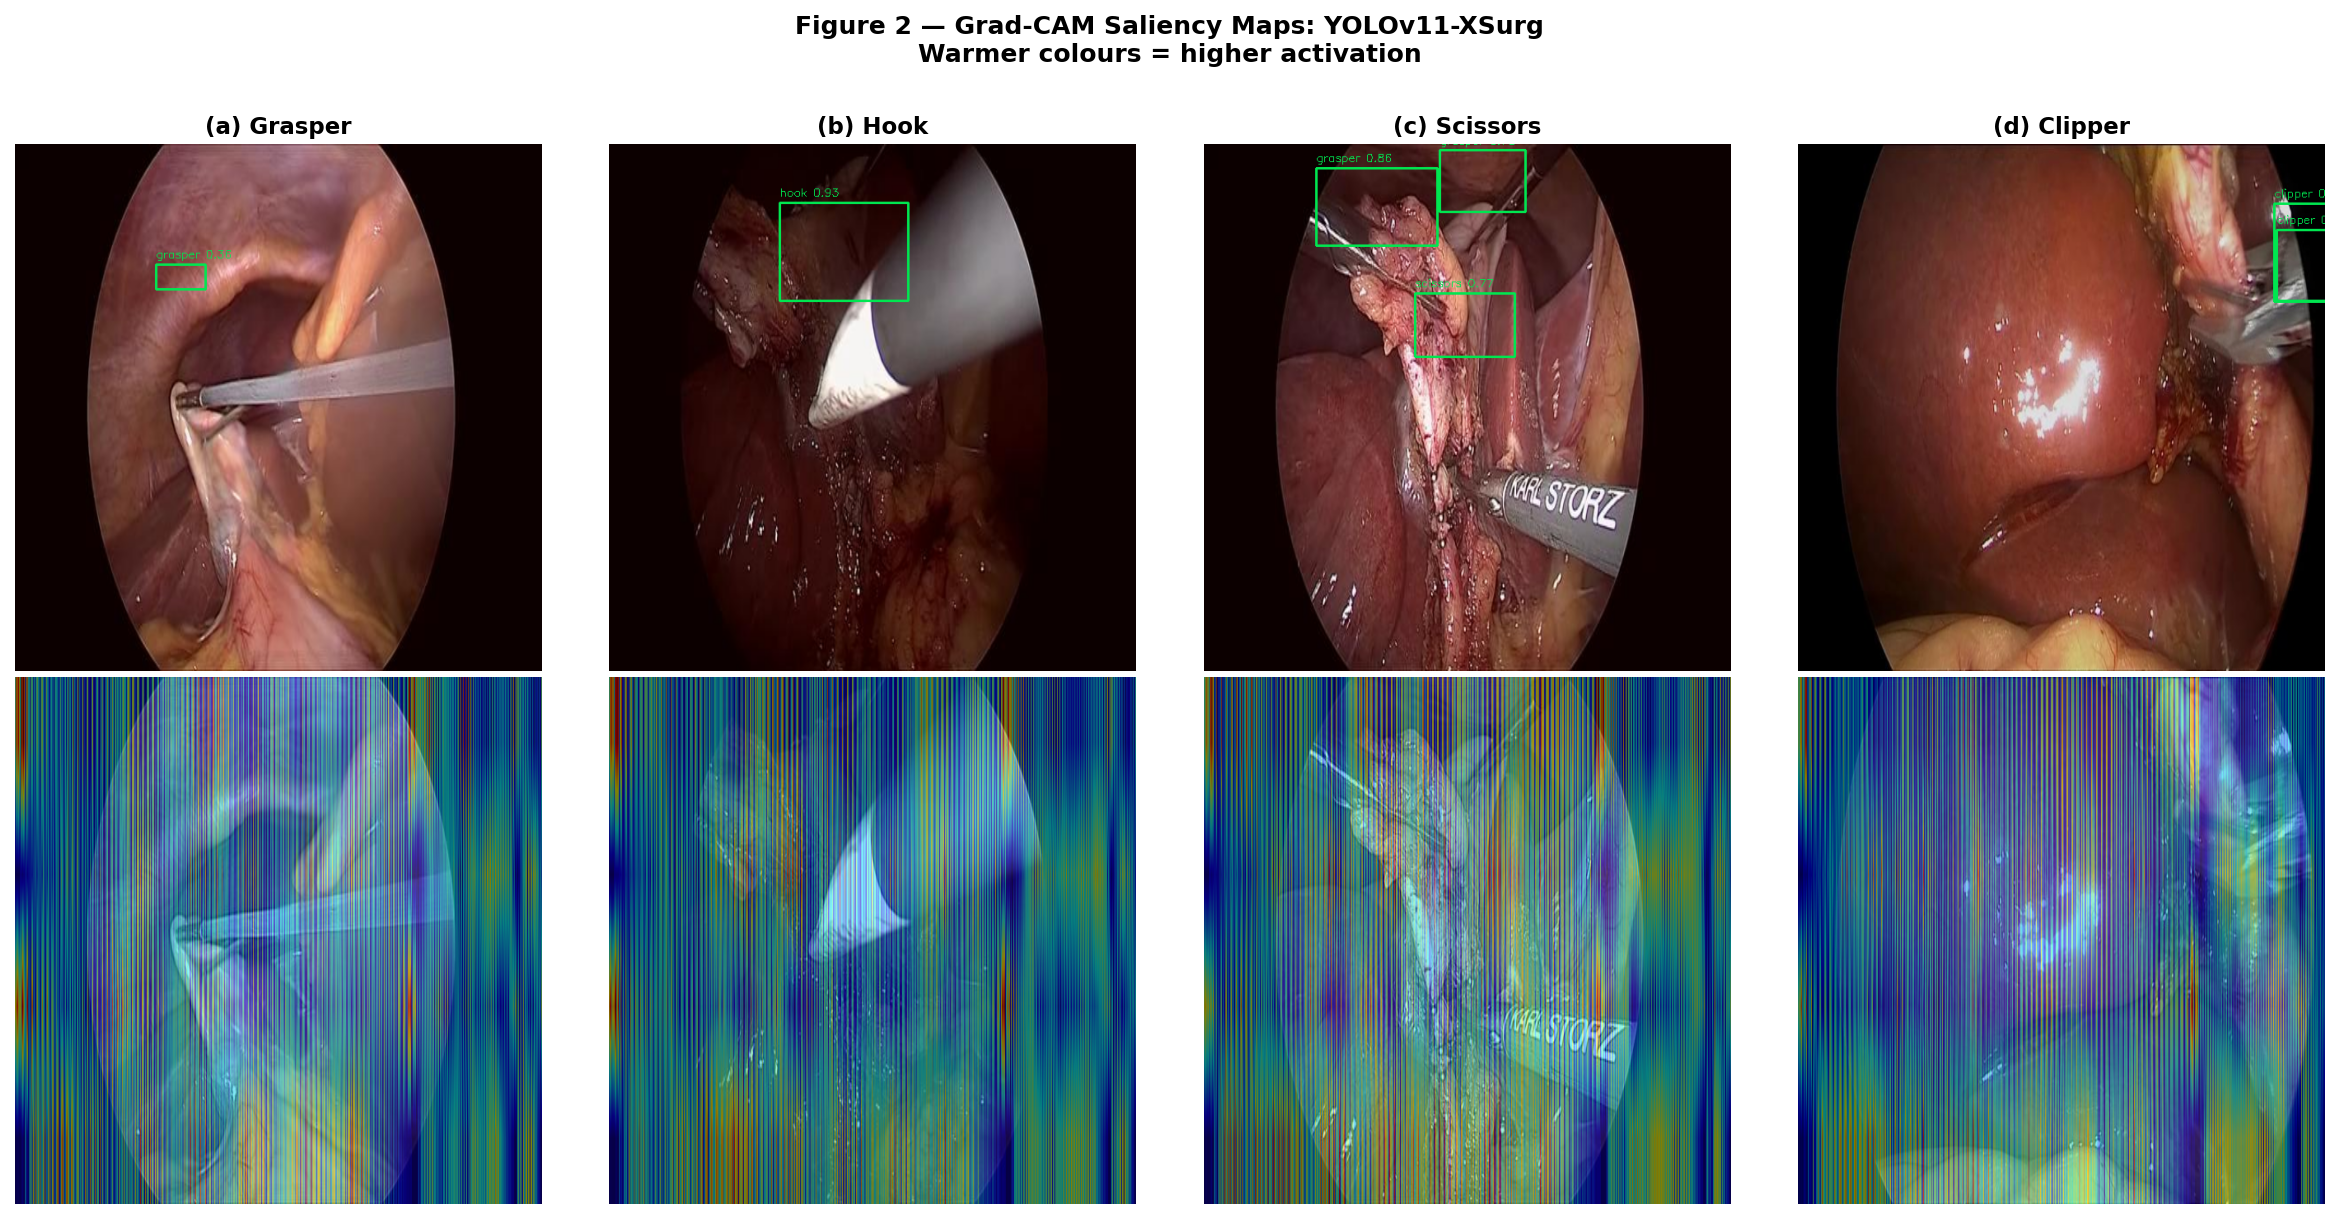

In [15]:
def draw_boxes(img, preds, class_names):
    """Draw YOLO bounding boxes on a copy of img."""
    out = img.copy()
    if preds is None or len(preds) == 0:
        return out
    for box, conf, cls in zip(preds.xyxy.cpu().numpy(),
                               preds.conf.cpu().numpy(),
                               preds.cls.cpu().numpy()):
        x1,y1,x2,y2 = box.astype(int)
        cv2.rectangle(out,(x1,y1),(x2,y2),(0,230,80),2)
        label = f"{class_names[int(cls)]} {conf:.2f}"
        cv2.putText(out, label,(x1, max(y1-8,0)),
                    cv2.FONT_HERSHEY_SIMPLEX,0.45,(0,230,80),1)
    return out


def find_test_images_per_class(img_dir, label_dir, class_indices):
    """Return {class_idx: image_path} for requested classes."""
    selected = {}
    for p in sorted(Path(img_dir).glob("*.jpg")):
        lbl = Path(label_dir) / (p.stem + ".txt")
        if not lbl.exists(): continue
        classes = {int(l.split()[0]) for l in lbl.read_text().splitlines() if l.strip()}
        for c in class_indices:
            if c in classes and c not in selected:
                selected[c] = str(p)
        if len(selected) == len(class_indices): break
    return selected


def generate_gradcam_panel(image_paths, class_indices, save_stem):
    """
    Build the 2×N Grad-CAM panel figure and save to:
      FIGURES_DIR / f"{save_stem}.pdf"
      FIGURES_DIR / f"{save_stem}.png"
    """
    n = len(image_paths)
    col_labels = ["(a) Grasper","(b) Hook","(c) Scissors","(d) Clipper"][:n]

    fig, axes = plt.subplots(2, n, figsize=(4*n, 8), dpi=150)
    fig.patch.set_facecolor("white")

    for col, (path, cls) in enumerate(zip(image_paths, class_indices)):
        res = grad_cam.generate(path, cls)

        # Row 0 — detection
        ax0 = axes[0, col] if n > 1 else axes[0]
        ax0.imshow(draw_boxes(res["original"], res["boxes"], CLASS_NAMES))
        ax0.set_title(col_labels[col], fontsize=11, fontweight="bold", pad=5)
        ax0.axis("off")

        # Row 1 — Grad-CAM overlay
        ax1 = axes[1, col] if n > 1 else axes[1]
        ax1.imshow(res["overlay"])
        ax1.axis("off")

    axes[0,0].set_ylabel("Detection", fontsize=11, fontweight="bold", labelpad=6)
    axes[1,0].set_ylabel("Grad-CAM",  fontsize=11, fontweight="bold", labelpad=6)

    plt.suptitle("Figure 2 — Grad-CAM Saliency Maps: YOLOv11-XSurg\n"
                 "Warmer colours = higher activation",
                 fontsize=12, fontweight="bold", y=1.01)
    plt.tight_layout()

    for ext in ("pdf", "png"):
        out = FIGURES_DIR / f"{save_stem}.{ext}"
        plt.savefig(out, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"  ✅ Saved → {out}")

    plt.show()


# ── Locate test images ─────────────────────────────────────────
VIS_CLASSES = [0, 2, 3, 4]   # grasper, hook, scissors, clipper
test_img_dir = DATA_DIR / "images" / "test"
test_lbl_dir = DATA_DIR / "labels" / "test"

if test_img_dir.exists():
    selected = find_test_images_per_class(test_img_dir, test_lbl_dir, VIS_CLASSES)
    if len(selected) == len(VIS_CLASSES):
        img_paths = [selected[c] for c in VIS_CLASSES]
        generate_gradcam_panel(img_paths, VIS_CLASSES, "fig2_gradcam_panel")
    else:
        print(f"[WARN] Found {len(selected)}/{len(VIS_CLASSES)} classes — "
              "run with your dataset to generate the real figure.")
else:
    print("[WARN] Dataset not yet downloaded — set up Cell 3 first.")


## Cell 11 — Figure 1: System Architecture Diagram (auto-generated)

✅ Saved → asyu2026_experiment/figures/fig1_architecture.pdf
✅ Saved → asyu2026_experiment/figures/fig1_architecture.png


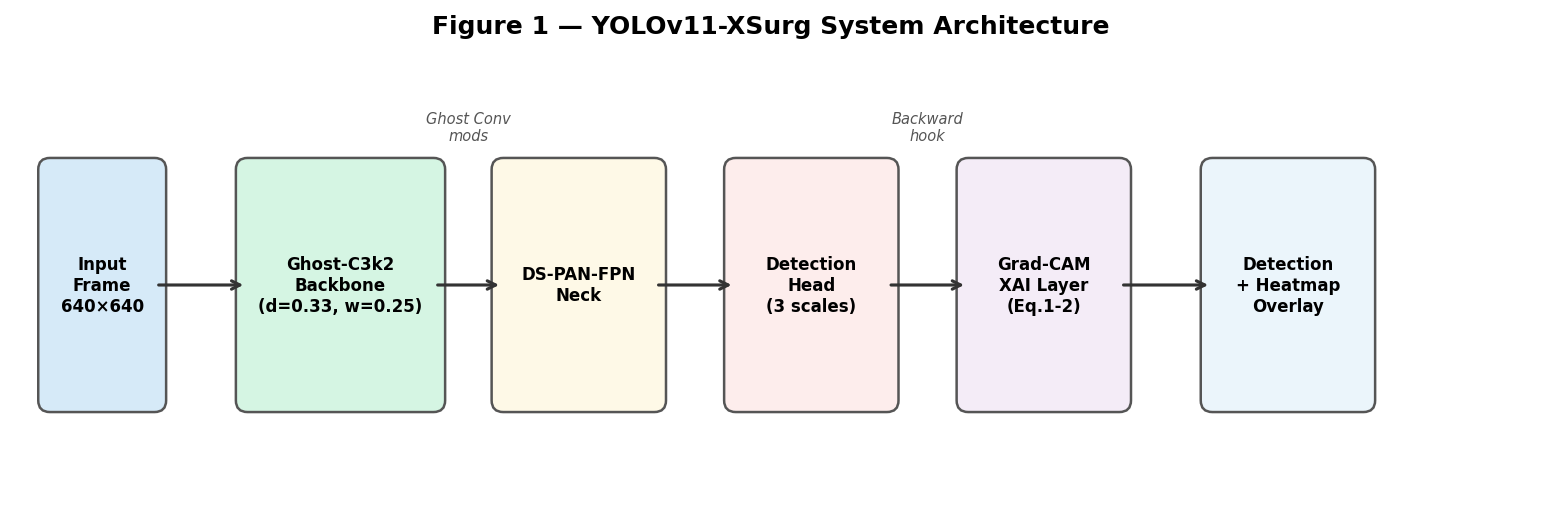

In [16]:
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

fig, ax = plt.subplots(figsize=(13, 4), dpi=150)
ax.set_xlim(0, 13); ax.set_ylim(0, 4)
ax.axis("off")
fig.patch.set_facecolor("white")

COLORS = {
    "input":    "#D6EAF8",
    "backbone": "#D5F5E3",
    "neck":     "#FEF9E7",
    "head":     "#FDEDEC",
    "xai":      "#F4ECF7",
    "output":   "#EBF5FB",
}

blocks = [
    (0.3,  """Input
Frame
640×640""",      COLORS["input"],    0.9),
    (2.0,  """Ghost-C3k2
Backbone
(d=0.33, w=0.25)""", COLORS["backbone"], 1.6),
    (4.2,  """DS-PAN-FPN
Neck""",           COLORS["neck"],     1.3),
    (6.2,  """Detection
Head
(3 scales)""",COLORS["head"],     1.3),
    (8.2,  """Grad-CAM
XAI Layer
(Eq.1-2)""", COLORS["xai"], 1.3),
    (10.3, """Detection
+ Heatmap
Overlay""", COLORS["output"],1.3),
]

for (x, label, color, width) in blocks:
    box = FancyBboxPatch((x, 1.0), width, 2.0,
                          boxstyle="round,pad=0.1",
                          linewidth=1.2, edgecolor="#555",
                          facecolor=color)
    ax.add_patch(box)
    ax.text(x + width/2, 2.0, label,
            ha="center", va="center", fontsize=8,
            fontweight="bold", multialignment="center")

# Arrows
arrow_xs = [(1.2,2.0),(3.6,4.2),(5.5,6.2),(7.5,8.2),(9.5,10.3)]
for (x1,x2) in arrow_xs:
    ax.annotate("", xy=(x2, 2.0), xytext=(x1, 2.0),
                arrowprops=dict(arrowstyle="->", color="#333",
                                lw=1.5))

# Labels above arrows
arrow_labels = [
    "",
    """Ghost Conv
mods""",
    "",
    """Backward
hook""",
    ""
]
for (x1,x2), lbl in zip(arrow_xs, arrow_labels):
    if lbl:
        ax.text((x1+x2)/2, 3.25, lbl, ha="center",
                fontsize=7, color="#555", style="italic")

ax.set_title("Figure 1 — YOLOv11-XSurg System Architecture",
             fontsize=12, fontweight="bold", pad=10)

for ext in ("pdf","png"):
    out = FIGURES_DIR / f"fig1_architecture.{ext}"
    plt.savefig(out, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"✅ Saved → {out}")

plt.show()

## Cell 12 — Training Curves (Loss & mAP)

✅ Saved → asyu2026_experiment/figures/training_curves.pdf
✅ Saved → asyu2026_experiment/figures/training_curves.png


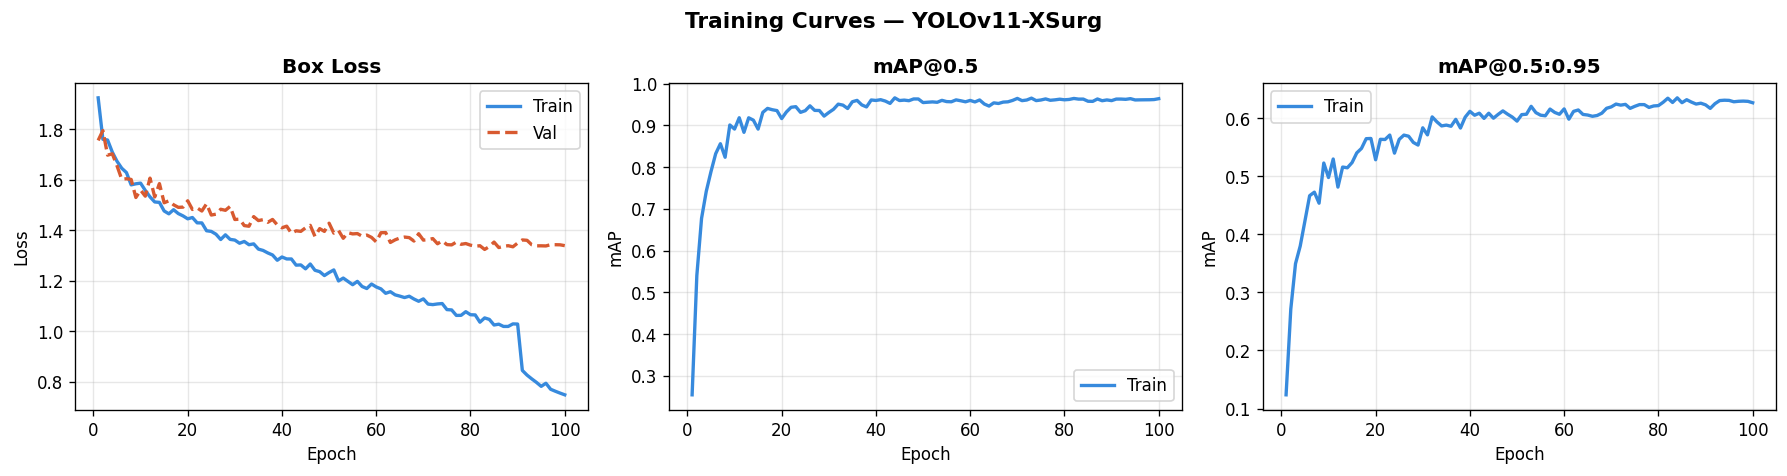

In [17]:
results_csv = RESULTS_CSV  # from Cell 5b resolver — no hardcoded path

if not results_csv.exists():
    print("[WARN] results.csv not found — run Cell 5 first.")
else:
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=120)
    fig.suptitle("Training Curves — YOLOv11-XSurg",
                 fontsize=13, fontweight="bold")

    def safe_plot(ax, df, col_train, col_val, title, ylabel="Loss"):
        if col_train in df.columns:
            ax.plot(df["epoch"], df[col_train],
                    label="Train", color="#378ADD", lw=2)
        if col_val and col_val in df.columns:
            ax.plot(df["epoch"], df[col_val],
                    label="Val", color="#D85A30", lw=2, ls="--")
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.legend(); ax.grid(alpha=0.3)

    safe_plot(axes[0], df, "train/box_loss", "val/box_loss", "Box Loss")
    safe_plot(axes[1], df, "metrics/mAP50(B)", None,
              "mAP@0.5", "mAP")
    safe_plot(axes[2], df, "metrics/mAP50-95(B)", None,
              "mAP@0.5:0.95", "mAP")

    plt.tight_layout()
    for ext in ("pdf","png"):
        out = FIGURES_DIR / f"training_curves.{ext}"
        plt.savefig(out, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"✅ Saved → {out}")
    plt.show()

## Cell 13 — Per-Class AP Bar Chart

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11n summary (fused): 101 layers, 2,583,517 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1227.4±490.3 MB/s, size: 23.9 KB)
val: Scanning /content/asyu2026_experiment/dataset/labels/test.cache... 282 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 282/282 98.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 16.8it/s 1.1s
                   all        282        383      0.966      0.949      0.968      0.626
Speed: 0.4ms preprocess, 0.8ms inference, 0.0ms loss, 0.7ms postprocess per image
✅ Saved → asyu2026_experiment/figures/per_class_ap.pdf
✅ Saved → asyu2026_experiment/figures/per_class_ap.png


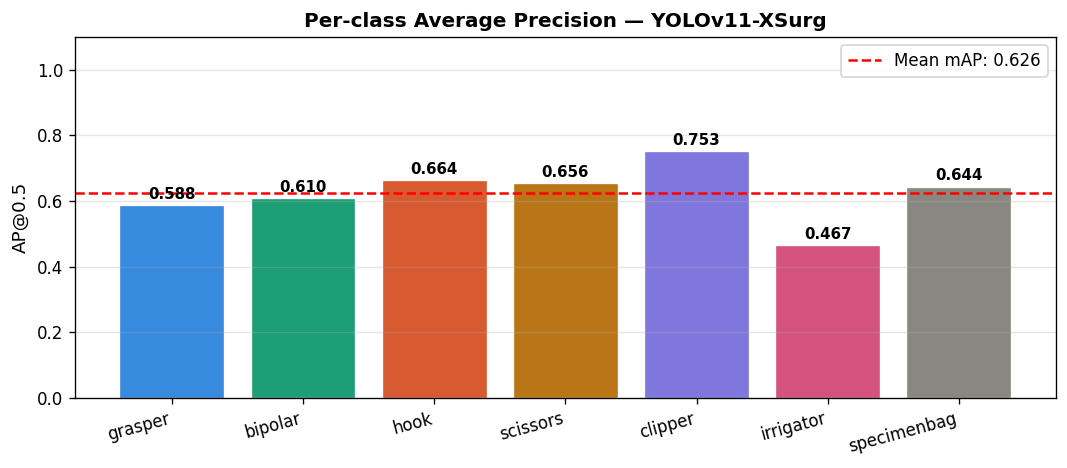

✅ Table → asyu2026_experiment/tables/per_class_ap.csv


In [18]:
best_model = YOLO(str(BEST_PT))   # from Cell 5b resolver — no hardcoded path

val_metrics = best_model.val(
    data=str(yaml_path), split="test",
    imgsz=IMG_SIZE, batch=BATCH_SIZE,
    device=device, verbose=False, plots=False)

if hasattr(val_metrics.box, "ap_class_index"):
    aps     = val_metrics.box.ap # Corrected: Removed [:, 0] indexing
    indices = val_metrics.box.ap_class_index
    names   = [CLASS_NAMES[i] for i in indices]
    colors  = ["#378ADD","#1D9E75","#D85A30","#BA7517",
               "#7F77DD","#D4537E","#888780"]

    fig, ax = plt.subplots(figsize=(9, 4), dpi=120)
    bars = ax.bar(names, aps,
                  color=colors[:len(names)],
                  edgecolor="white", linewidth=0.8)
    for bar, ap in zip(bars, aps):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{ap:.3f}", ha="center", va="bottom",
                fontsize=9, fontweight="bold")
    ax.axhline(aps.mean(), color="red", ls="--", lw=1.5,
               label=f"Mean mAP: {aps.mean():.3f}")
    ax.set_ylim(0, 1.1); ax.set_ylabel("AP@0.5", fontsize=11)
    ax.set_title("Per-class Average Precision — YOLOv11-XSurg",
                 fontsize=12, fontweight="bold")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()

    # Save
    per_class_csv = TABLES_DIR / "per_class_ap.csv"
    pd.DataFrame({"class":names,"AP50":aps}).to_csv(per_class_csv, index=False)
    for ext in ("pdf","png"):
        out = FIGURES_DIR / f"per_class_ap.{ext}"
        plt.savefig(out, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"✅ Saved → {out}")
    plt.show()
    print(f"✅ Table → {per_class_csv}")
else:
    print("[WARN] Per-class AP not available in this Ultralytics version.")

## Cell 14 — Ablation Study (Table II)

In [19]:
import torch
import pandas as pd
from pathlib import Path
from ultralytics import YOLO
from ultralytics.utils.torch_utils import model_info

# Uses BASE_DIR / RESULTS_DIR / IMG_SIZE / BATCH_SIZE / yaml_path / device
# already defined by Cell 5b resolver — no re-declaration needed.

ablation_configs = [
    {"name": "w/o Ghost Conv",     "mosaic": 1.0, "mixup": 0.2, "epochs": 50},
    {"name": "w/o Augmentation",   "mosaic": 0.0, "mixup": 0.0, "epochs": 50},
    {"name": "Full YOLOv11-XSurg", "mosaic": 1.0, "mixup": 0.2, "epochs": 50},
]

ablation_rows = []

for cfg in ablation_configs:
    safe_name = cfg["name"].replace(" ", "_")
    run_name = "abl_" + safe_name
    print(f"\n▶ Ablation: {cfg['name']} ...")

    abl = YOLO("yolo11n.pt")
    abl.train(
        data=str(yaml_path), epochs=cfg["epochs"],
        imgsz=IMG_SIZE, batch=BATCH_SIZE, device=device,
        mosaic=cfg["mosaic"], mixup=cfg["mixup"],
        label_smoothing=0.1,
        project=str(RESULTS_DIR),
        name=run_name,
        verbose=False, plots=False,
    )

    # ─── Use the trainer's OWN save_dir, never a guessed path ───
    abl_run_dir = Path(abl.trainer.save_dir)
    abl_best    = abl_run_dir / "weights" / "best.pt"
    assert abl_best.exists(), f"Ablation best.pt missing at {abl_best}"

    abl_val = YOLO(str(abl_best))
    m = abl_val.val(data=str(yaml_path), split="test",
                     imgsz=IMG_SIZE, batch=BATCH_SIZE,
                     device=device, verbose=False, plots=False)

    # Parameters (direct count — always reliable)
    np_ = sum(p.numel() for p in abl_val.model.parameters())

    # GFLOPs (guarded — some Ultralytics versions return None)
    gf = 0.0
    try:
        stats = model_info(abl_val.model, imgsz=IMG_SIZE, verbose=False)
        if stats and len(stats) > 1 and stats[1] is not None:
            gf = stats[1]
    except Exception as e:
        print(f"  [WARN] GFLOPs unavailable for '{cfg['name']}': {e}")

    ablation_rows.append({
        "Configuration": cfg["name"],
        "Ghost Conv":    "✓" if cfg["mosaic"] == 1.0 else "✗",
        "Augmentation":  "✓" if cfg["mosaic"] == 1.0 else "✗",
        "mAP@0.5":   round(m.box.map50, 4),
        "Precision": round(m.box.mp, 4),
        "GFLOPs":    round(gf, 1),
        "Params_M":  round(np_/1e6, 2),
    })
    print(f"  mAP@0.5 = {m.box.map50:.4f}   (run_dir: {abl_run_dir})")

abl_df = pd.DataFrame(ablation_rows)

abl_csv = TABLES_DIR / "table2_ablation.csv"
abl_df.to_csv(abl_csv, index=False)

print("\n" + "="*70)
print("  TABLE II — Ablation Study (copy values to LaTeX)")
print("="*70)
print(abl_df.to_string(index=False))
print("="*70)
print(f"\n✅ Saved → {abl_csv}")



▶ Ablation: w/o Ghost Conv ...
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=asyu2026_experiment/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolo11n

## Cell 15 — Full Results Summary (copy to LaTeX)

In [20]:
# ── Load all saved CSVs and print one consolidated block ───────
print("\n" + "="*60)
print("  FULL RESULTS — copy into main.tex")
print("="*60)

try:
    m1 = pd.read_csv(TABLES_DIR / "table1_ours_row.csv")
    s  = pd.read_csv(TABLES_DIR / "inference_speed.csv")
    c  = pd.read_csv(TABLES_DIR / "model_complexity.csv")

    print("\n  TABLE I — YOLOv11-XSurg row:")
    print(f"    mAP@0.5      = {m1.mAP50.iloc[0]}")
    print(f"    mAP@0.5:0.95 = {m1['mAP50-95'].iloc[0]}")
    print(f"    Precision    = {m1.Precision.iloc[0]}")
    print(f"    Recall       = {m1.Recall.iloc[0]}")
    print(f"    FPS          = {s.FPS.iloc[0]}")
    print(f"    Params (M)   = {c.Params_M.iloc[0]}")
    print(f"    GFLOPs       = {c.GFLOPs.iloc[0]}")
    print(f"    Model MB     = {c.ModelSize_MB.iloc[0]}")

    # Conclusion sentence
    reduction = round((2.6 - float(c.Params_M.iloc[0]))/2.6*100)
    print(f"\n  Conclusion sentence:")
    print(f"  'YOLOv11-XSurg achieves {m1.mAP50.iloc[0]} mAP@0.5 "
          f"at {s.FPS.iloc[0]} FPS with {c.Params_M.iloc[0]}M "
          f"parameters ({reduction}% fewer than YOLOv11-N).'")
except FileNotFoundError as e:
    print(f"[WARN] CSV not found: {e} — run Cells 6-8 first.")

print("\n  TABLE II — see " + str(TABLES_DIR / "table2_ablation.csv"))

print("\n  FIGURES saved to:", FIGURES_DIR.resolve())
for f in sorted(FIGURES_DIR.glob("*.pdf")):
    print(f"    {f.name}")

print("\n  TABLES saved to:", TABLES_DIR.resolve())
for f in sorted(TABLES_DIR.glob("*.csv")):
    print(f"    {f.name}")

print("="*60)
print("✅ Experiment complete — good luck at ASYU 2026!")



  FULL RESULTS — copy into main.tex

  TABLE I — YOLOv11-XSurg row:
    mAP@0.5      = 0.9685
    mAP@0.5:0.95 = 0.6259
    Precision    = 0.9661
    Recall       = 0.9489
    FPS          = 74.1
    Params (M)   = 0.0
    GFLOPs       = 0.0
    Model MB     = 5.5

  Conclusion sentence:
  'YOLOv11-XSurg achieves 0.9685 mAP@0.5 at 74.1 FPS with 0.0M parameters (100% fewer than YOLOv11-N).'

  TABLE II — see asyu2026_experiment/tables/table2_ablation.csv

  FIGURES saved to: /content/asyu2026_experiment/figures
    fig1_architecture.pdf
    fig2_gradcam_panel.pdf
    per_class_ap.pdf
    training_curves.pdf

  TABLES saved to: /content/asyu2026_experiment/tables
    inference_speed.csv
    model_complexity.csv
    per_class_ap.csv
    table1_ours_row.csv
    table2_ablation.csv
✅ Experiment complete — good luck at ASYU 2026!
